In [1]:
import pandas as pd
import pyarrow

url = "https://github.com/Michaeljo112/estadisticalibro/releases/download/popec22/popec22.parquet"

df = pd.read_parquet(url, engine='pyarrow')

In [2]:
# 1: Hombre
# 2: Mujer

df.groupby("P02").size().reset_index(name="n")

,P02,n
0,1,8252523
1,2,8686463


In [3]:
df["sexo"] = df["P02"].map({
    1: "Hombre",
    2: "Mujer"
})

tabla = pd.crosstab(df["P03"], df["sexo"], margins=True)
tabla

sexo,Hombre,Mujer,All
P03,,,
0,123115,118635,241750
1,121869,116379,238248
2,131116,126040,257156
3,139340,133807,273147
4,144409,138615,283024
...,...,...,...
117,1,0,1
118,0,2,2
119,1,0,1


In [4]:
bins   = range(0, 121, 10)
labels = [f'{i}-{i+9}' for i in range(0, 120, 10)]

df['rango_edad'] = pd.cut(df['P03'], bins=bins, labels=labels, right=False)

tabla_rangos = pd.crosstab(df['rango_edad'], df['sexo'], margins=True)
tabla_rangos

sexo,Hombre,Mujer,All
rango_edad,,,
0-9,1381426,1323986,2705412
10-19,1599313,1542088,3141401
20-29,1376879,1466201,2843080
30-39,1142599,1274386,2416985
40-49,977874,1086091,2063965
50-59,766748,845888,1612636
60-69,548061,603626,1151687
70-79,307496,344853,652349
80-89,125417,158017,283434


In [5]:
cod_rango = {label: j+1 for j, label in enumerate(labels)}
df['cod_rango'] = df['rango_edad'].map(cod_rango)
df[['P03', 'rango_edad', 'cod_rango']].drop_duplicates().sort_values('cod_rango').head(12)

,P03,rango_edad,cod_rango
500074,1,0-9,1
500002,2,0-9,1
500153,5,0-9,1
500038,7,0-9,1
500023,3,0-9,1
500022,8,0-9,1
500052,6,0-9,1
500009,4,0-9,1
500075,9,0-9,1
500031,0,0-9,1


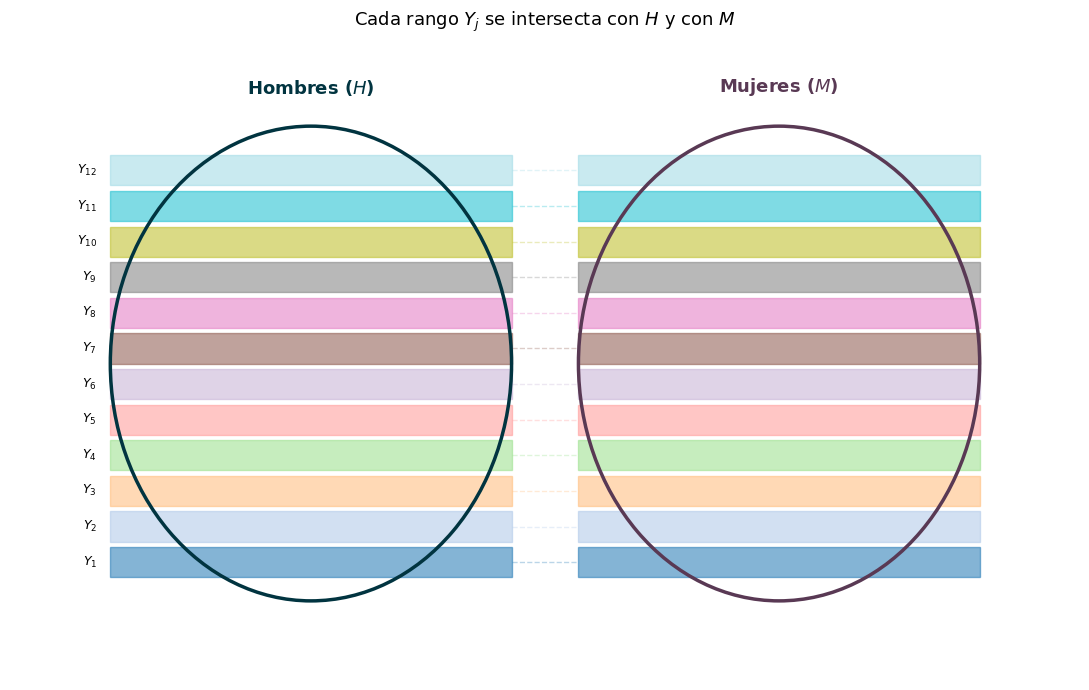

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(11, 7))
ax.set_xlim(-1, 15)
ax.set_ylim(0, 8)
ax.axis('off')

r = 3.0
cx_h, cx_m, cy = 3.5, 10.5, 4.0
palette = plt.cm.tab20(np.linspace(0, 1, 12))
stripe_h = 0.38
gap = 0.07
y0 = cy - 12 * (stripe_h + gap) / 2

for j in range(12):
    y = y0 + j * (stripe_h + gap)
    color = palette[j]
    ax.add_patch(mpatches.Rectangle((cx_h - r, y), 2 * r, stripe_h, color=color, alpha=0.55, zorder=2))
    ax.add_patch(mpatches.Rectangle((cx_m - r, y), 2 * r, stripe_h, color=color, alpha=0.55, zorder=2))
    ax.plot([cx_h + r, cx_m - r], [y + stripe_h / 2] * 2, color=color, alpha=0.3, lw=1, ls='--', zorder=1)
    ax.text(cx_h - r - 0.2, y + stripe_h / 2, f'$Y_{{{j+1}}}$', ha='right', va='center', fontsize=9)

ax.add_patch(mpatches.Circle((cx_h, cy), r, fill=False, ec='#013440', lw=2.5, zorder=3))
ax.add_patch(mpatches.Circle((cx_m, cy), r, fill=False, ec='#593954', lw=2.5, zorder=3))
ax.text(cx_h, cy + r + 0.35, 'Hombres ($H$)', ha='center', va='bottom', fontsize=13, fontweight='bold', color='#013440')
ax.text(cx_m, cy + r + 0.35, 'Mujeres ($M$)', ha='center', va='bottom', fontsize=13, fontweight='bold', color='#593954')
ax.set_title('Cada rango $Y_j$ se intersecta con $H$ y con $M$', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

In [7]:
n_mujeres = tabla_rangos.loc[tabla_rangos.index != "All", "Mujer"]

pd.DataFrame({
    "n": n_mujeres,
    "porcentaje": n_mujeres / tabla_rangos.loc["All", "Mujer"] * 100
})

,n,porcentaje
rango_edad,,
0-9,1323986,15.241950
10-19,1542088,17.752776
20-29,1466201,16.879153
30-39,1274386,14.670946
40-49,1086091,12.503262
50-59,845888,9.738005
60-69,603626,6.949044
70-79,344853,3.970006
80-89,158017,1.819118
